In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from string import punctuation 
from nltk.tokenize import word_tokenize
from nltk.stem import LancasterStemmer

from string import punctuation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings('ignore')

In [43]:
reviews = pd.read_excel ("CombinedData.xlsx")
reviews.head()

,VisitingDate,Year,Age,Ethnicity,DeafOrDisabled,UKResidence,Postcode,residenceCountry,Gender,ThreeWordsExperience,otherFeedback
0,16/03/2021,2021-22,55 - 59,White: English/Welsh/Scottish/Northern Irish/B...,Yes,Yes,WV16 6NW,NaN,Male,Inspiring Relaxing Engaging,NaN
1,16/03/2022,2021-22,55 - 59,Prefer not to say,No,Yes,WV16 6NW,NaN,Female,Awesome Welcoming Engaging,No
2,15/03/2022,2021-22,35 - 39,White: Other,No,No,NaN,France,Female,Fun Great Friendly,NaN
3,15/03/2022,2021-22,35 - 39,White: Other,No,No,NaN,France,Male,Fun Exciting Learning,Very good/enjoyable
4,19/03/2022,2021-22,50 - 54,White: English/Welsh/Scottish/Northern Irish/B...,No,Yes,CV34 4JT,NaN,Male,Amazing Fantastic Wow,A fantastic museum and approach to interpretin...


In [44]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   VisitingDate          1449 non-null   object
 1   Year                  1449 non-null   object
 2   Age                   1449 non-null   object
 3   Ethnicity             1449 non-null   object
 4   DeafOrDisabled        1449 non-null   object
 5   UKResidence           1449 non-null   object
 6   Postcode              1240 non-null   object
 7   residenceCountry      89 non-null     object
 8   Gender                1300 non-null   object
 9   ThreeWordsExperience  1257 non-null   object
 10  otherFeedback         570 non-null    object
dtypes: object(11)
memory usage: 124.7+ KB


In [45]:
import pandas as pd
import re

# Example DataFrame
# reviews = pd.read_csv('your_data.csv')  # Load your actual data

# Function to remove unnecessary characters, correct spelling, and convert to lowercase
def clean_and_correct_spelling(text):
    text = str(text).lower()  # Convert to lowercase
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Correct spelling
    corrected_text = []
    for word in text.split():
        corrected_word = spell.correction(word)
        # Ensure corrected_word is a valid string, otherwise use the original word
        if corrected_word:
            corrected_text.append(corrected_word)
        else:
            corrected_text.append(word)
    corrected_text = ' '.join(corrected_text)
    # Remove extra whitespace
    corrected_text = re.sub(r'\s+', ' ', corrected_text).strip()
    return corrected_text

# Check if the column exists before applying the function
if 'ThreeWordsExperience' in reviews.columns:
    reviews['ThreeWordsExperience'] = reviews['ThreeWordsExperience'].apply(clean_and_correct_spelling)
else:
    print("Column 'ThreeWordsExperience' does not exist in the DataFrame.")


In [46]:
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity  # Returns a polarity score between -1 and 1

reviews['ThreeWordsExperienceSentiment'] = reviews['ThreeWordsExperience'].apply(get_sentiment)

# Categorize sentiment into positive, neutral, and negative
reviews['ThreeWordsExperience_SentimentCategory'] = reviews['ThreeWordsExperienceSentiment'].apply(
    lambda score: 'positive' if score > 0.1 else ('negative' if score < -0.1 else 'neutral')
)

In [33]:
# Save the results back to an Excel file
#reviews.to_excel('Lapworth_with_sentiment.xlsx', index=False)

In [47]:
import pandas as pd
import re

# Example DataFrame
# reviews = pd.read_csv('your_data.csv')  # Load your actual data

# Function to remove unnecessary characters, correct spelling, and convert to lowercase
def clean_and_correct_spelling(text):
    text = str(text).lower()  # Convert to lowercase
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Correct spelling
    corrected_text = []
    for word in text.split():
        corrected_word = spell.correction(word)
        # Ensure corrected_word is a valid string, otherwise use the original word
        if corrected_word:
            corrected_text.append(corrected_word)
        else:
            corrected_text.append(word)
    corrected_text = ' '.join(corrected_text)
    # Remove extra whitespace
    corrected_text = re.sub(r'\s+', ' ', corrected_text).strip()
    return corrected_text

# Check if the column exists before applying the function
if 'otherFeedback' in reviews.columns:
    reviews['otherFeedback'] = reviews['otherFeedback'].apply(clean_and_correct_spelling)
else:
    print("Column 'ThreeWordsExperience' does not exist in the DataFrame.")


In [48]:
reviews.head()

,VisitingDate,Year,Age,Ethnicity,DeafOrDisabled,UKResidence,Postcode,residenceCountry,Gender,ThreeWordsExperience,otherFeedback,ThreeWordsExperienceSentiment,ThreeWordsExperience_SentimentCategory
0,16/03/2021,2021-22,55 - 59,White: English/Welsh/Scottish/Northern Irish/B...,Yes,Yes,WV16 6NW,NaN,Male,inspiring relaxing engaging,nan,0.450000,positive
1,16/03/2022,2021-22,55 - 59,Prefer not to say,No,Yes,WV16 6NW,NaN,Female,awesome welcoming engaging,no,0.700000,positive
2,15/03/2022,2021-22,35 - 39,White: Other,No,No,NaN,France,Female,fun great friendly,nan,0.491667,positive
3,15/03/2022,2021-22,35 - 39,White: Other,No,No,NaN,France,Male,fun exciting learning,very goodenjoyable,0.300000,positive
4,19/03/2022,2021-22,50 - 54,White: English/Welsh/Scottish/Northern Irish/B...,No,Yes,CV34 4JT,NaN,Male,amazing fantastic wow,a fantastic museum and approach to interpretin...,0.366667,positive


In [49]:
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity  # Returns a polarity score between -1 and 1

reviews['otherFeedback_Sentiment'] = reviews['otherFeedback'].apply(get_sentiment)

# Categorize sentiment into positive, neutral, and negative
reviews['otherFeedback_SentimentCategory'] = reviews['otherFeedback_Sentiment'].apply(
    lambda score: 'positive' if score > 0.1 else ('negative' if score < -0.1 else 'neutral')
)

In [50]:
reviews.head()

,VisitingDate,Year,Age,Ethnicity,DeafOrDisabled,UKResidence,Postcode,residenceCountry,Gender,ThreeWordsExperience,otherFeedback,ThreeWordsExperienceSentiment,ThreeWordsExperience_SentimentCategory,otherFeedback_Sentiment,otherFeedback_SentimentCategory
0,16/03/2021,2021-22,55 - 59,White: English/Welsh/Scottish/Northern Irish/B...,Yes,Yes,WV16 6NW,NaN,Male,inspiring relaxing engaging,nan,0.450000,positive,0.0,neutral
1,16/03/2022,2021-22,55 - 59,Prefer not to say,No,Yes,WV16 6NW,NaN,Female,awesome welcoming engaging,no,0.700000,positive,0.0,neutral
2,15/03/2022,2021-22,35 - 39,White: Other,No,No,NaN,France,Female,fun great friendly,nan,0.491667,positive,0.0,neutral
3,15/03/2022,2021-22,35 - 39,White: Other,No,No,NaN,France,Male,fun exciting learning,very goodenjoyable,0.300000,positive,0.2,positive
4,19/03/2022,2021-22,50 - 54,White: English/Welsh/Scottish/Northern Irish/B...,No,Yes,CV34 4JT,NaN,Male,amazing fantastic wow,a fantastic museum and approach to interpretin...,0.366667,positive,0.4,positive


In [51]:
# Save the results back to an Excel file
reviews.to_excel('Lapworth_with_sentiment.xlsx', index=False)

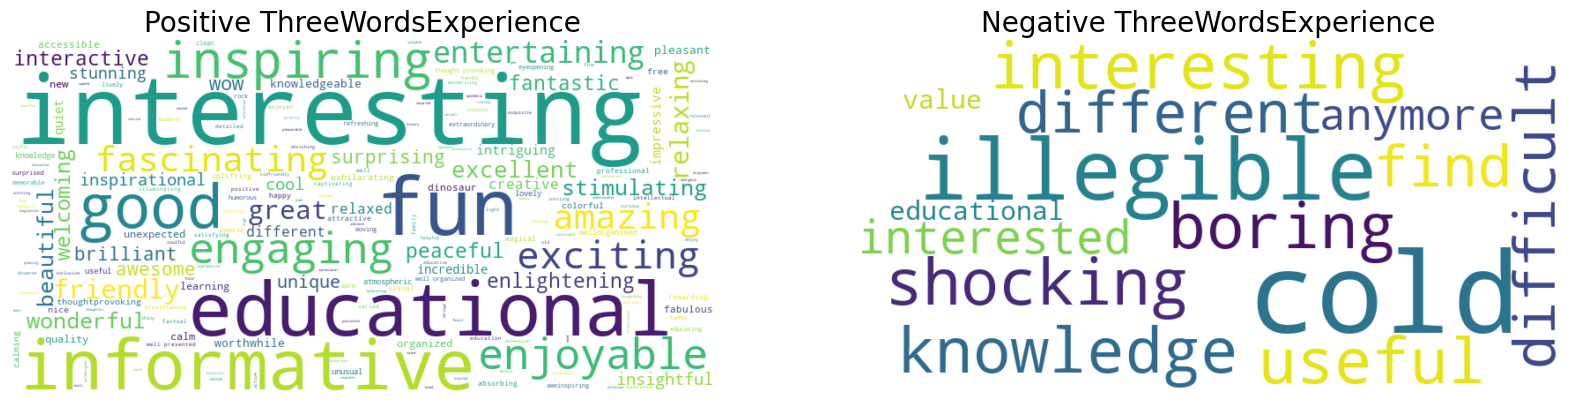

In [52]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter positive and negative experiences
positive_reviews = reviews[reviews['ThreeWordsExperience_SentimentCategory'] == 'positive']
negative_reviews = reviews[reviews['ThreeWordsExperience_SentimentCategory'] == 'negative']

# Combine text for word clouds
positive_text = ' '.join(positive_reviews['ThreeWordsExperience'])
negative_text = ' '.join(negative_reviews['ThreeWordsExperience'])

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

# Plot the word clouds
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(positive_wordcloud, interpolation='bilinear')
axes[0].set_title('Positive ThreeWordsExperience', fontsize=20)
axes[0].axis('off')

axes[1].imshow(negative_wordcloud, interpolation='bilinear')
axes[1].set_title('Negative ThreeWordsExperience', fontsize=20)
axes[1].axis('off')

plt.show()


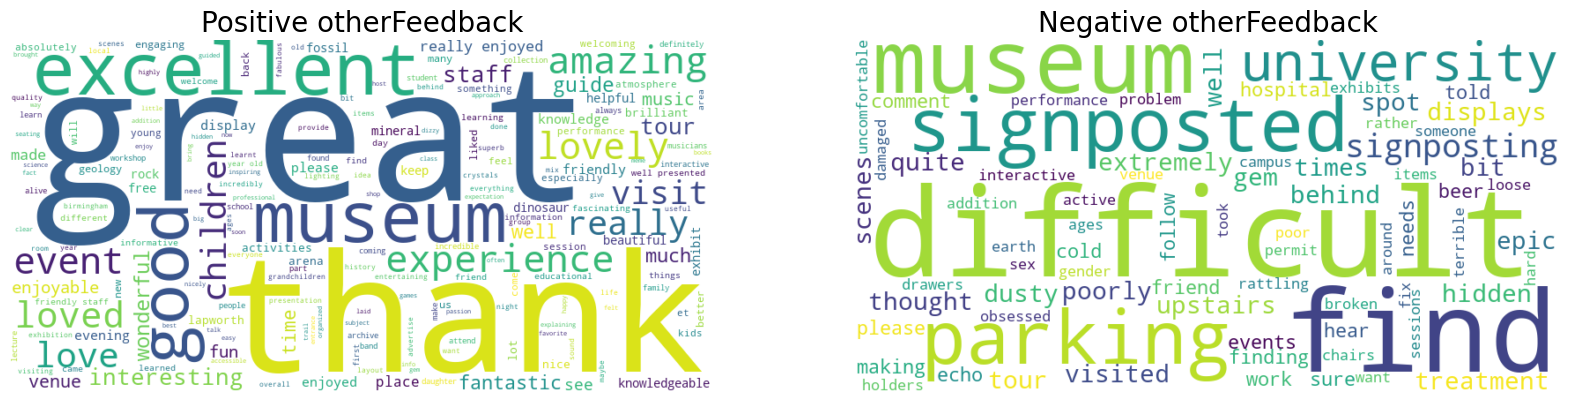

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter positive and negative experiences
positive_reviews = reviews[reviews['otherFeedback_SentimentCategory'] == 'positive']
negative_reviews = reviews[reviews['otherFeedback_SentimentCategory'] == 'negative']

# Combine text for word clouds
positive_text = ' '.join(positive_reviews['otherFeedback'])
negative_text = ' '.join(negative_reviews['otherFeedback'])

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

# Plot the word clouds
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(positive_wordcloud, interpolation='bilinear')
axes[0].set_title('Positive otherFeedback', fontsize=20)
axes[0].axis('off')

axes[1].imshow(negative_wordcloud, interpolation='bilinear')
axes[1].set_title('Negative otherFeedback', fontsize=20)
axes[1].axis('off')

plt.show()


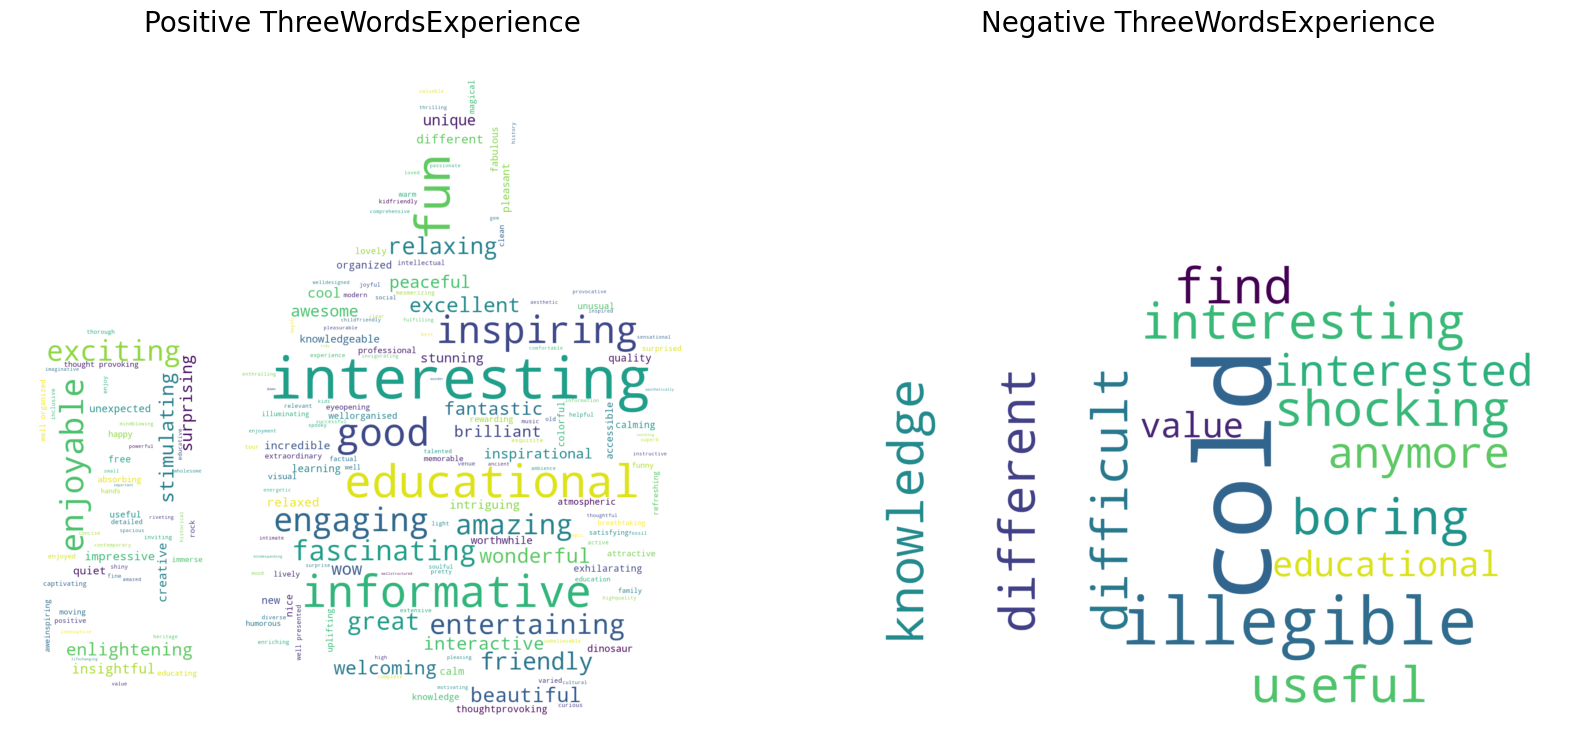

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Filter positive and negative experiences
positive_reviews = reviews[reviews['ThreeWordsExperience_SentimentCategory'] == 'positive']
negative_reviews = reviews[reviews['ThreeWordsExperience_SentimentCategory'] == 'negative']

# Combine text for word clouds
positive_text = ' '.join(positive_reviews['ThreeWordsExperience'])
negative_text = ' '.join(negative_reviews['ThreeWordsExperience'])

# Load thumbs up and thumbs down mask images
thumbs_up_mask = np.array(Image.open("thumbs_up.jpg"))
thumbs_down_mask = np.array(Image.open("thumbs_up.jpg"))

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white', mask=thumbs_up_mask).generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white', mask=thumbs_down_mask).generate(negative_text)

# Plot the word clouds
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(positive_wordcloud, interpolation='bilinear')
axes[0].set_title('Positive ThreeWordsExperience', fontsize=20)
axes[0].axis('off')

axes[1].imshow(negative_wordcloud, interpolation='bilinear')
axes[1].set_title('Negative ThreeWordsExperience', fontsize=20)
axes[1].axis('off')

plt.show()


In [55]:
df= reviews

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/norahalmakinzi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


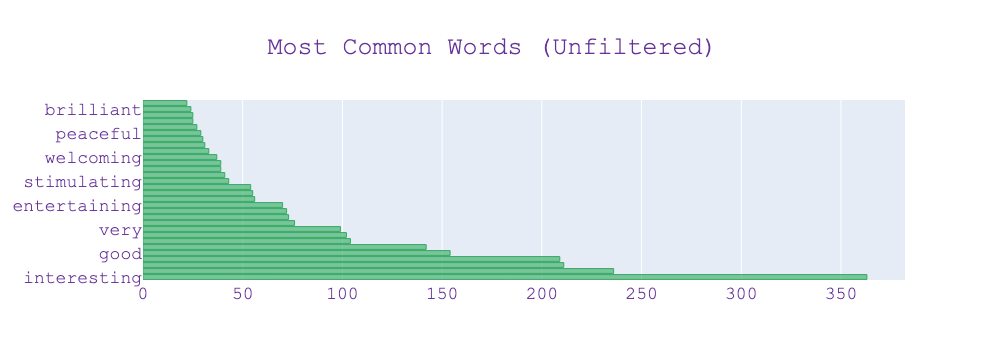

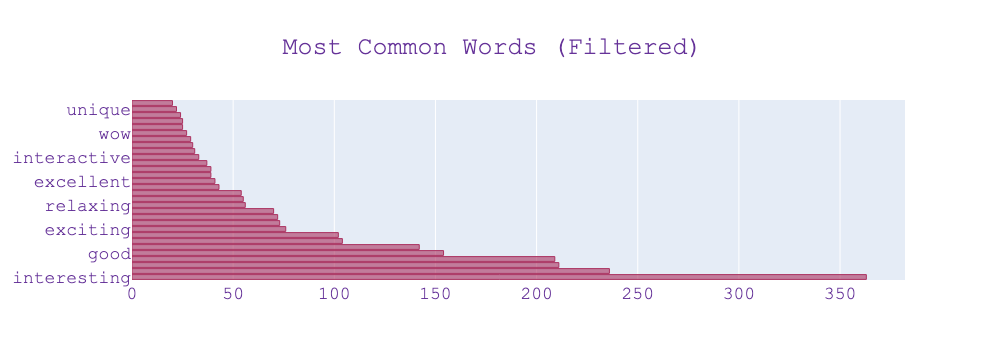

In [59]:
from collections import Counter
import plotly.graph_objs as go
import pandas as pd
from nltk.corpus import stopwords

# Ensure you've downloaded the stopwords data
import nltk
nltk.download('stopwords')

# Define stop words
stopWords_nltk = set(stopwords.words('english'))

# Assuming df is your DataFrame
texts = df['ThreeWordsExperience']
new = texts.str.split()
new = new.values.tolist()
corpus = [word for i in new for word in i if word.lower() != 'nan']
counter = Counter(corpus)
most = counter.most_common()

# Unfiltered list
x_unfiltered, y_unfiltered = [], []
for word, count in most[:30]:
    x_unfiltered.append(word)
    y_unfiltered.append(count)

# Filtered list
x_filtered, y_filtered = [], []
for word, count in most:
    if word.lower() not in stopWords_nltk and word.lower() != 'nan':
        x_filtered.append(word)
        y_filtered.append(count)

# Plot unfiltered words
fig_unfiltered = go.Figure(go.Bar(
            x=y_unfiltered,
            y=x_unfiltered,
            orientation='h',  
            marker=dict(
                color='rgba(50, 171, 96, 0.6)',
                line=dict(
                    color='rgba(50, 171, 96, 1.0)',
                    width=1
                ),
            ),
            name='Most Common Words (Unfiltered)',
))

fig_unfiltered.update_layout(
    title={
        'text': "Most Common Words (Unfiltered)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }, 
    font=dict(
        family="Courier New, monospace",
        size=18,
        color="RebeccaPurple"
    )
)

# Plot filtered words
fig_filtered = go.Figure(go.Bar(
            x=y_filtered[:30],  # Limit to top 30
            y=x_filtered[:30],
            orientation='h',  
            marker=dict(
                color='rgba(171, 50, 96, 0.6)',
                line=dict(
                    color='rgba(171, 50, 96, 1.0)',
                    width=1
                ),
            ),
            name='Most Common Words (Filtered)',
))

fig_filtered.update_layout(
    title={
        'text': "Most Common Words (Filtered)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }, 
    font=dict(
        family="Courier New, monospace",
        size=18,
        color="RebeccaPurple"
    )
)

fig_unfiltered.show()
fig_filtered.show()


In [60]:
fig = make_subplots(rows=1, cols=3)
title_ = ["negative", "neutral", "positive"]

for i in range(3):
    texts = df[df["ThreeWordsExperience_SentimentCategory"] == i]['ThreeWordsExperience']

    new = texts.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]
    counter = Counter(corpus)
    most = counter.most_common()
    x, y = [], []

    for word, count in most[:30]:
        if word not in stopWords_nltk:
            x.append(word)
            y.append(count)

    fig.add_trace(go.Bar(
                x=y,
                y=x,
                orientation='h', type="bar",
        name=title_[i], marker=dict(color=colors[i])), 1, i+1)
    
fig.update_layout(
    autosize=False,
    width=2000,
    height=600,title=dict(
        text='<b>Most Common ngrams per Classes</b>',
        x=0.5,
        y=0.95,
        font=dict(
        family="Courier New, monospace",
        size=24,
        color="RebeccaPurple"
        )
    ),)


fig.show()

NameError: name 'make_subplots' is not defined

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/norahalmakinzi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


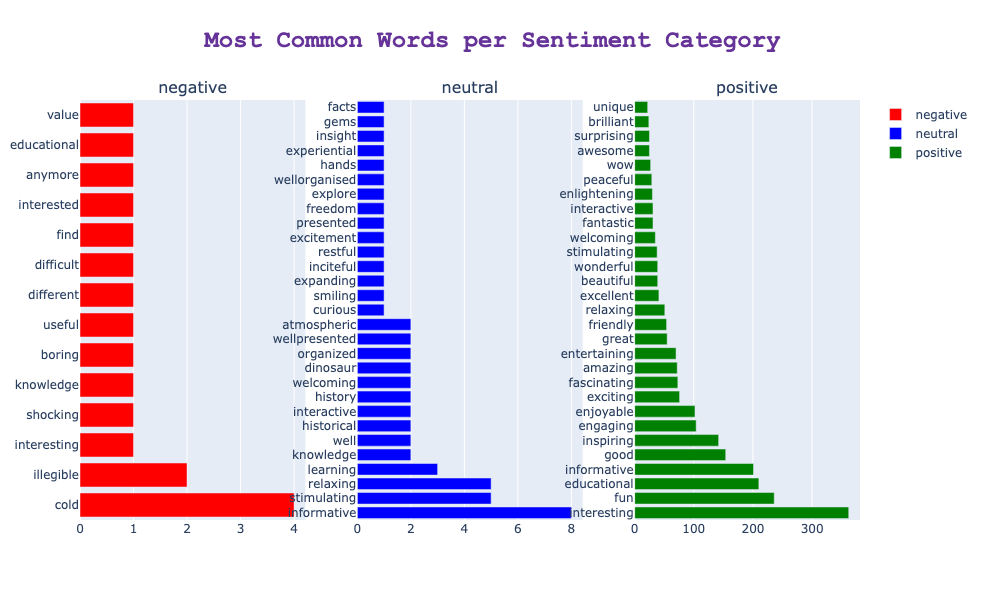